In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pathlib import Path
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler


In [48]:
url = 'C:/Users/Lenovo/Desktop/BUC/1st Sem/CET 313 - Artificial Intelligence/ASSIGNMENT/Customer.csv'

# List files in the directory
print([file.name for file in Path(url).parent.iterdir() if file.is_file()])

# Read the CSV file
customer_data = pd.read_csv(url)

# Print DataFrame dimensions
print(f'Dataframe dimensions: {customer_data.shape}')


['Customer.csv', 'customersegmentation.ipynb', 'notes.txt']
Dataframe dimensions: (2000, 8)


In [49]:
# Display the first 15 rows of the data
display(customer_data.head(15))


,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6
5,6,Female,22,58000,76,Artist,0,2
6,7,Female,35,31000,6,Healthcare,1,3
7,8,Female,23,84000,94,Healthcare,1,3
8,9,Male,64,97000,3,Engineer,0,3
9,10,Female,30,98000,72,Artist,1,4


In [50]:
# Check for null values in 'CustomerID' and display relevant info
nan_count_customer_id = customer_data['CustomerID'].isnull().sum()

print(f'NaN values in CustomerID: {nan_count_customer_id}')

# Display the total number of entries and the dimensions of the DataFrame
print(f'Dataframe dimensions: {customer_data.shape}')

# Display the data
display(customer_data)


NaN values in CustomerID: 0
Dataframe dimensions: (2000, 8)


,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6
...,...,...,...,...,...,...,...,...
1995,1996,Female,71,184387,40,Artist,8,7
1996,1997,Female,91,73158,32,Doctor,7,7
1997,1998,Male,87,90961,14,Healthcare,9,2
1998,1999,Male,77,182109,4,Executive,7,2


In [51]:
# Check for duplicates in the DataFrame
duplicate_count = customer_data.duplicated().sum()
print(f'Duplicates: {duplicate_count}')


Duplicates: 0


In [52]:
# Create a DataFrame with column types, null values count, and null values percentage
data_info = pd.DataFrame({
    'column type': customer_data.dtypes,
    'null values (nb)': customer_data.isnull().sum(),
    'null values (%)': customer_data.isnull().mean() * 100
})

# Display the info DataFrame 
display(data_info)


,column type,null values (nb),null values (%)
CustomerID,int64,0,0.00
Gender,object,0,0.00
Age,int64,0,0.00
Annual Income ($),int64,0,0.00
Spending Score (1-100),int64,0,0.00
Profession,object,35,1.75
Work Experience,int64,0,0.00
Family Size,int64,0,0.00


In [53]:
# Group the data by 'CustomerID', 'Gender', and 'Profession', and count occurrences
grouped_data = (
    customer_data[['CustomerID', 'Gender', 'Profession']]
    .groupby(['CustomerID', 'Gender', 'Profession'])
    .count()
    .reset_index()
)

# Count occurrences of each profession
profession_counts = grouped_data['Profession'].value_counts()

# Count total entries in the Profession column
total_professions = grouped_data['Profession'].count()

# Print the results
print("Total Number of Unique Professions:", len(profession_counts))
print(profession_counts)
print("Total of All Professions:", total_professions)


Total Number of Unique Professions: 9
Profession
Artist           612
Healthcare       339
Entertainment    234
Engineer         179
Doctor           161
Executive        153
Lawyer           142
Marketing         85
Homemaker         60
Name: count, dtype: int64
Total of All Professions: 1965


In [54]:
# Display rows where the 'Profession' column is null
display(customer_data[customer_data['Profession'].isna()])


,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
79,80,Female,49,98000,42,NaN,1,1
118,119,Female,51,84000,43,NaN,2,7
219,220,Female,59,76000,61,NaN,9,1
237,238,Male,95,36000,35,NaN,0,4
437,438,Male,76,136259,14,NaN,0,7
440,441,Female,0,57373,29,NaN,0,7
498,499,Male,95,121725,3,NaN,12,3
545,546,Female,89,107359,26,NaN,10,6
601,602,Male,61,126370,20,NaN,11,4
641,642,Male,66,121377,19,NaN,7,7


In [55]:
# Create a mask for rows where 'Profession' was originally NaN
mask = customer_data['Profession'].isna()

# Store the original values before filling
original_values = customer_data.loc[mask, 'Profession'].copy()

# Fill missing values in the 'Profession' column with the mode
customer_data['Profession'] = customer_data['Profession'].fillna(customer_data['Profession'].mode()[0])

# Create a DataFrame to show which rows were filled
filled_rows = customer_data[mask].copy()
filled_rows['Original_Profession'] = original_values
filled_rows['Filled_Profession'] = customer_data.loc[mask, 'Profession']

# Display the rows where values were filled
display(filled_rows)

# Filter the customer data to retrieve rows where the 'Profession' column is still null
remaining_nulls = customer_data[customer_data['Profession'].isnull()]

# Display the remaining rows with null values
display(remaining_nulls)


,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size,Original_Profession,Filled_Profession
79,80,Female,49,98000,42,Artist,1,1,NaN,Artist
118,119,Female,51,84000,43,Artist,2,7,NaN,Artist
219,220,Female,59,76000,61,Artist,9,1,NaN,Artist
237,238,Male,95,36000,35,Artist,0,4,NaN,Artist
437,438,Male,76,136259,14,Artist,0,7,NaN,Artist
440,441,Female,0,57373,29,Artist,0,7,NaN,Artist
498,499,Male,95,121725,3,Artist,12,3,NaN,Artist
545,546,Female,89,107359,26,Artist,10,6,NaN,Artist
601,602,Male,61,126370,20,Artist,11,4,NaN,Artist
641,642,Male,66,121377,19,Artist,7,7,NaN,Artist


,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size


In [56]:
# Summary statistics for numerical variables in the customer data
customer_data.describe()


,CustomerID,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,48.960000,110731.821500,50.962500,4.102500,3.768500
std,577.494589,28.429747,45739.536688,27.934661,3.922204,1.970749
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,500.750000,25.000000,74572.000000,28.000000,1.000000,2.000000
50%,1000.500000,48.000000,110045.000000,50.000000,3.000000,4.000000
75%,1500.250000,73.000000,149092.750000,75.000000,7.000000,5.000000
max,2000.000000,99.000000,189974.000000,100.000000,17.000000,9.000000


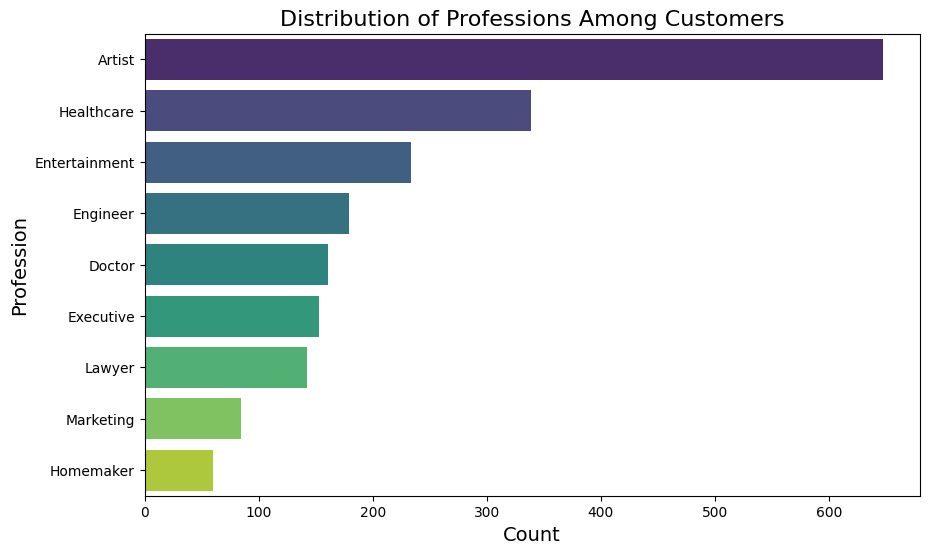

In [57]:
# Count occurrences of each profession
profession_distribution = customer_data['Profession'].value_counts()

# Create a horizontal bar plot with a color palette
plt.figure(figsize=(10, 6))
sns.barplot(x=profession_distribution.values, y=profession_distribution.index, 
            hue=profession_distribution.index, palette='viridis', dodge=False)

# Add titles and labels
plt.title('Distribution of Professions Among Customers', fontsize=16)
plt.xlabel('Count', fontsize=14)
plt.ylabel('Profession', fontsize=14)

# Show the plot
plt.show()


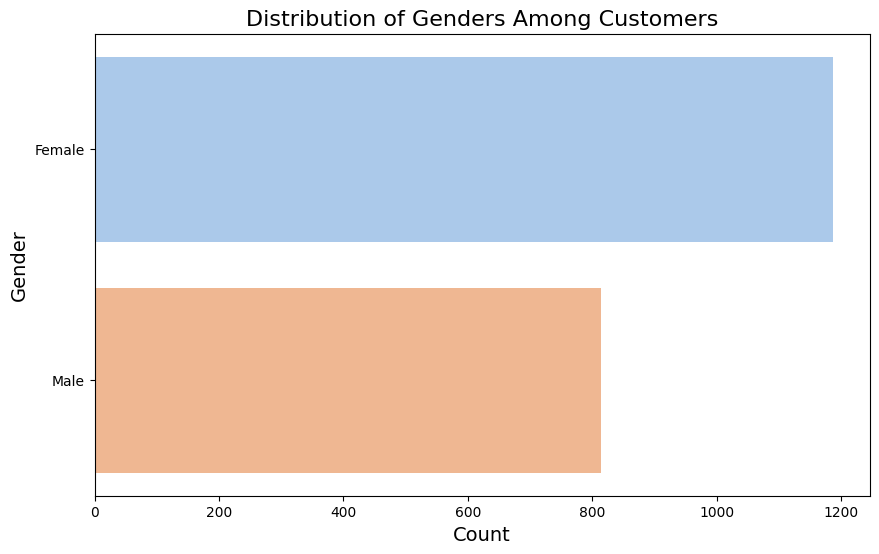

In [58]:
# Count occurrences of each gender
gender_distribution = customer_data['Gender'].value_counts()

# Create a horizontal bar plot with a color palette
plt.figure(figsize=(10, 6))
sns.barplot(x=gender_distribution.values, y=gender_distribution.index, hue=gender_distribution.index, palette='pastel', dodge=False)

# Add titles and labels
plt.title('Distribution of Genders Among Customers', fontsize=16)
plt.xlabel('Count', fontsize=14)
plt.ylabel('Gender', fontsize=14)

# Show the plot
plt.show()


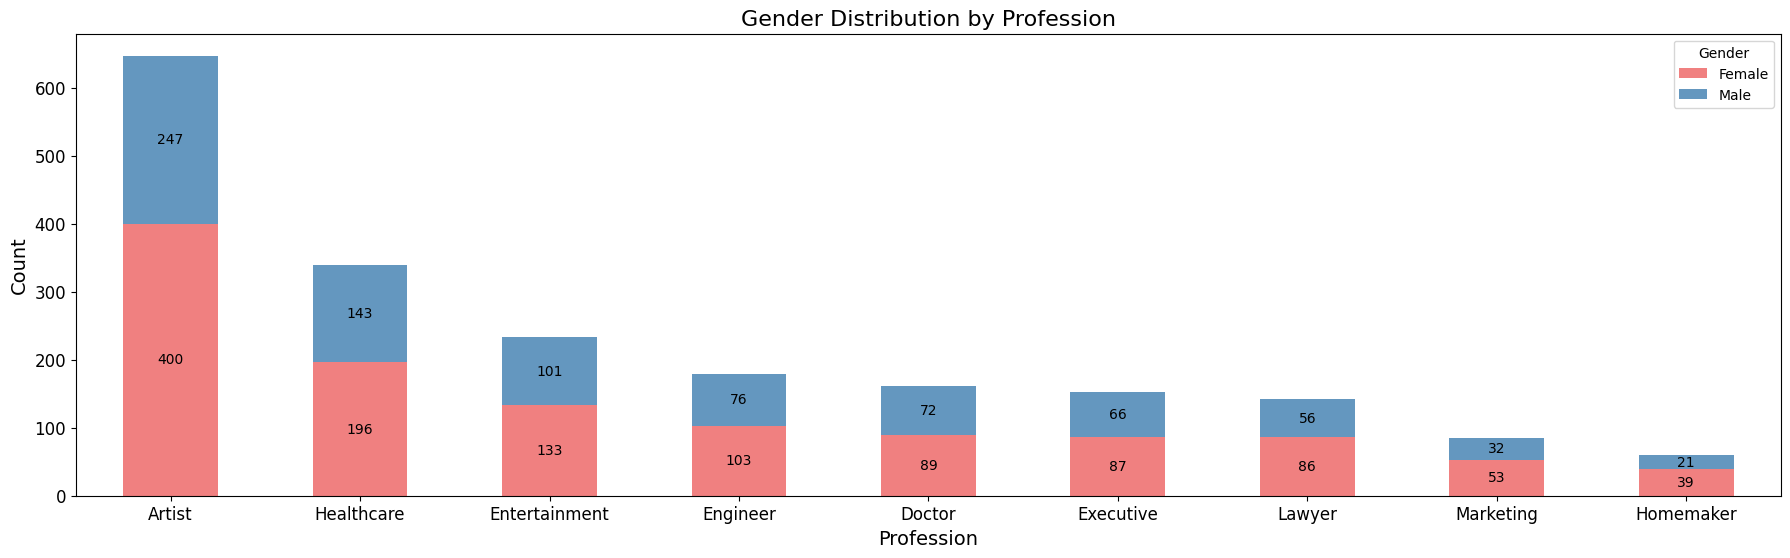

In [59]:
# Create a cross-tabulation of professions by gender
profession_gender_counts = pd.crosstab(customer_data['Profession'], customer_data['Gender'])

# Sort indices based on the total count of each profession
sorted_professions = (profession_gender_counts["Female"] + profession_gender_counts["Male"]).sort_values(ascending=False).index 

# Create a stacked bar plot for profession vs. gender with specified colors
ax = profession_gender_counts.loc[sorted_professions, :].plot(
    kind="bar", 
    stacked=True, 
    figsize=(22, 6), 
    color=['#F08080', '#6497BF']
)

# Set x and y ticks
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

# Add labels to the bars
ax.bar_label(ax.containers[0], label_type='center')
ax.bar_label(ax.containers[1], label_type='center')

# Add titles and labels
plt.title('Gender Distribution by Profession', fontsize=16)
plt.xlabel('Profession', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Show the plot
plt.show()


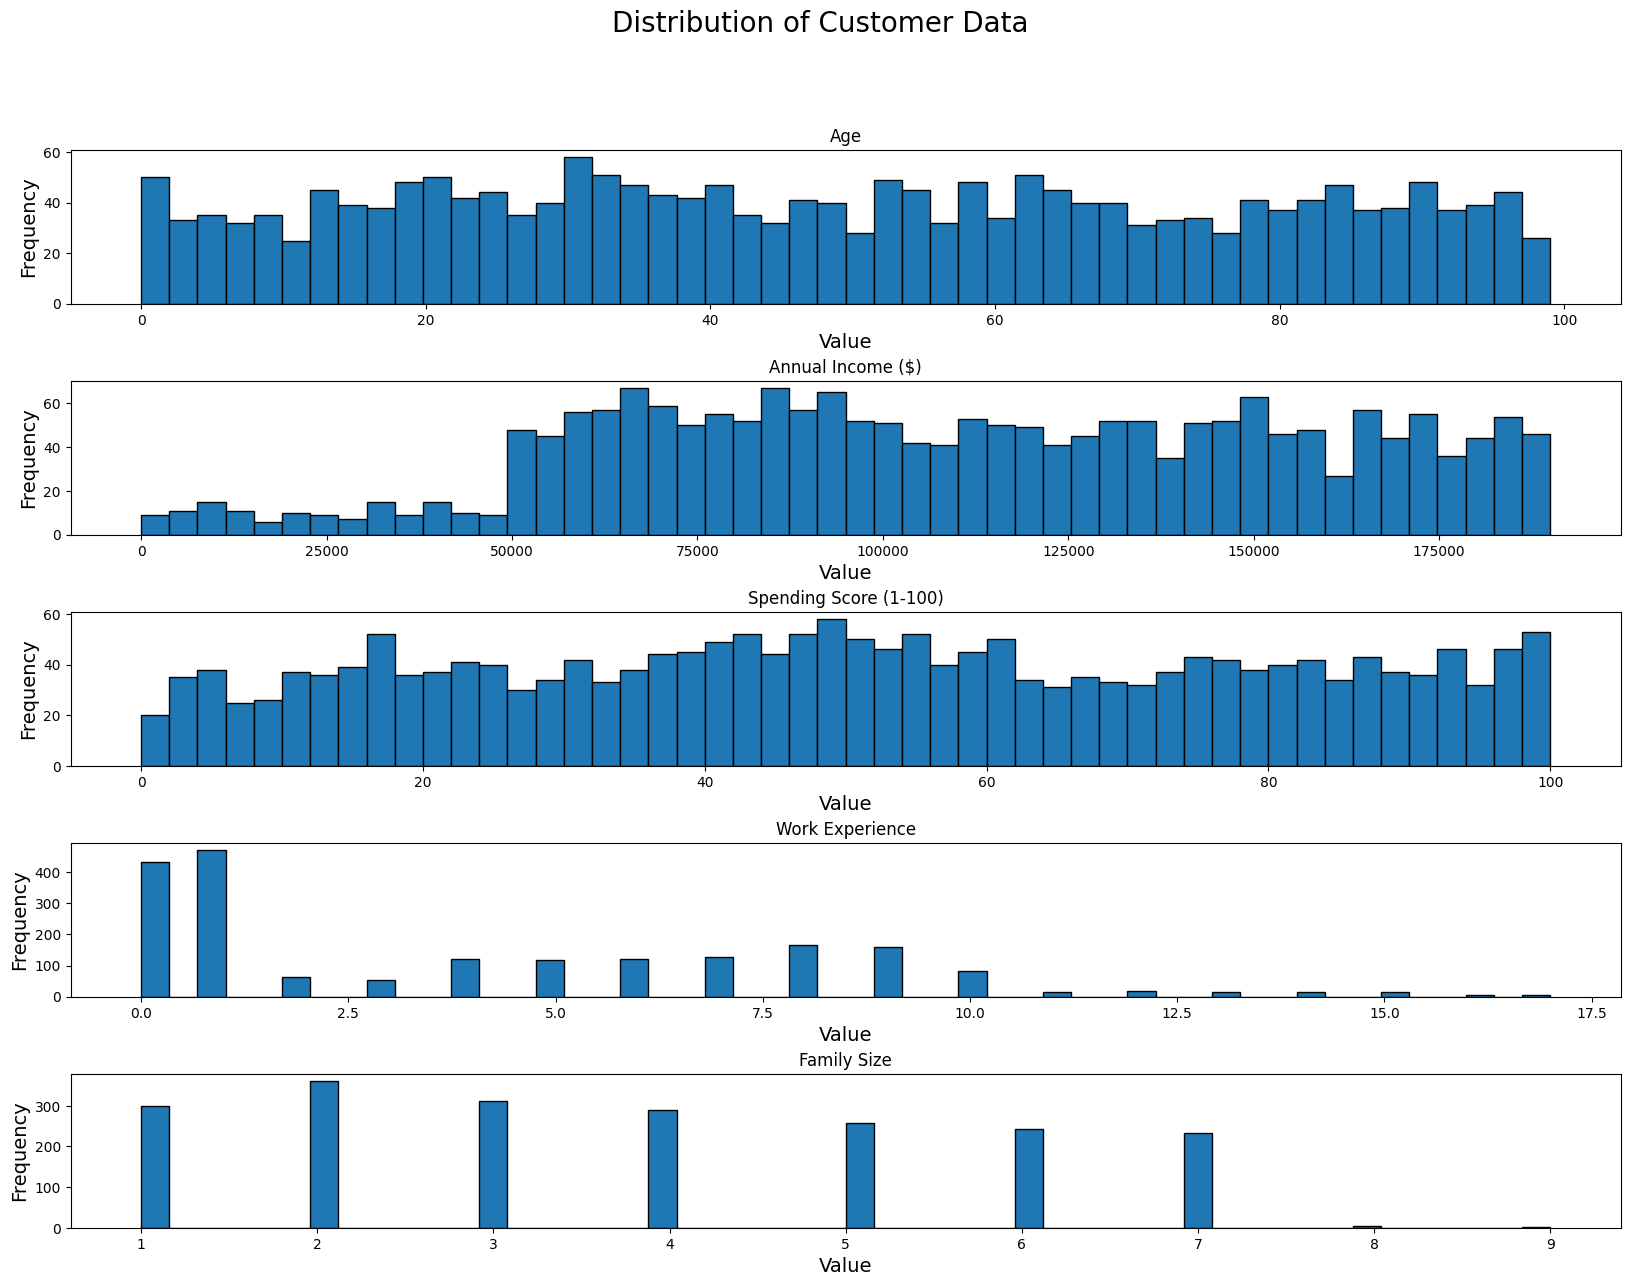

In [60]:
# Exclude 'CustomerID' and select only numeric columns
numeric_data = customer_data.drop(columns=['CustomerID']).select_dtypes(include=['number'])
num_cols = numeric_data.shape[1]

plt.figure(figsize=(20, 14))

# Create histograms for each numeric column
for i, column in enumerate(numeric_data.columns):
    plt.subplot(num_cols, 1, i + 1)  # Create a subplot for each column
    plt.hist(numeric_data[column], bins=50, edgecolor='black')
    plt.title(column) 
    plt.xlabel('Value', fontsize=14) 
    plt.ylabel('Frequency', fontsize=14)

# Adjust the layout to add spacing
plt.subplots_adjust(hspace=0.5)

# Title for the entire figure
plt.suptitle('Distribution of Customer Data', fontsize=20)

# Show the plot
plt.show()


In [61]:
# Define the features for analysis: Annual Income and Spending Score
features_name = ['Annual Income ($)', 'Spending Score (1-100)']
features = customer_data[features_name]

# List to store the indices of outliers
outliers_index = []

# Loop through each feature to identify outliers
for column in features_name:
    # Calculate the first (Q1) and third (Q3) quartiles
    Q1 = features[column].quantile(0.25)
    Q3 = features[column].quantile(0.75)
    
    # Calculate the Interquartile Range (IQR)
    IQR = Q3 - Q1

    # Determine the lower and upper bounds for outlier detection
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers based on the bounds
    outliers = features[(features[column] < lower_bound) | (features[column] > upper_bound)]
    
    # Collect the indices of identified outliers
    for idx in outliers.index:
        if idx not in outliers_index:
            outliers_index.append(idx)
    
    # Print the number of outliers found for the current feature
    print(f"Number of outliers in {column}: {len(outliers)}")


Number of outliers in Annual Income ($): 0
Number of outliers in Spending Score (1-100): 0


In [62]:
# Create an instance of MinMaxScaler for normalization
minmax_scaler = MinMaxScaler()

# Fit and transform the features
normalized_features = minmax_scaler.fit_transform(features)

# Convert the normalized data back into a DataFrame with the same column names
normalized_features_df = pd.DataFrame(normalized_features, columns=features.columns)

# Calculate and display the peak-to-peak range for the raw numerical features
print(f"Peak to Peak range by column in Raw        :\n{np.ptp(features, axis=0)}")   

# Calculate and display the peak-to-peak range for the normalized features
print(f"Peak to Peak range by column in Normalized :\n{np.ptp(normalized_features_df, axis=0)}")

# Print the normalized features
print(normalized_features_df)


Peak to Peak range by column in Raw        :
Annual Income ($)         189974
Spending Score (1-100)       100
dtype: int64
Peak to Peak range by column in Normalized :
Annual Income ($)         1.0
Spending Score (1-100)    1.0
dtype: float64
      Annual Income ($)  Spending Score (1-100)
0              0.078958                    0.39
1              0.184236                    0.81
2              0.452694                    0.06
3              0.310569                    0.77
4              0.200027                    0.40
...                 ...                     ...
1995           0.970591                    0.40
1996           0.385095                    0.32
1997           0.478808                    0.14
1998           0.958600                    0.04
1999           0.582238                    0.52

[2000 rows x 2 columns]


In [63]:
# Get statistics for the normalized features DataFrame
normalized_statistics = normalized_features_df.describe()

# Display the statistics
display(normalized_statistics)


,Annual Income ($),Spending Score (1-100)
count,2000.000000,2000.000000
mean,0.582879,0.509625
std,0.240767,0.279347
min,0.000000,0.000000
25%,0.392538,0.280000
50%,0.579263,0.500000
75%,0.784806,0.750000
max,1.000000,1.000000


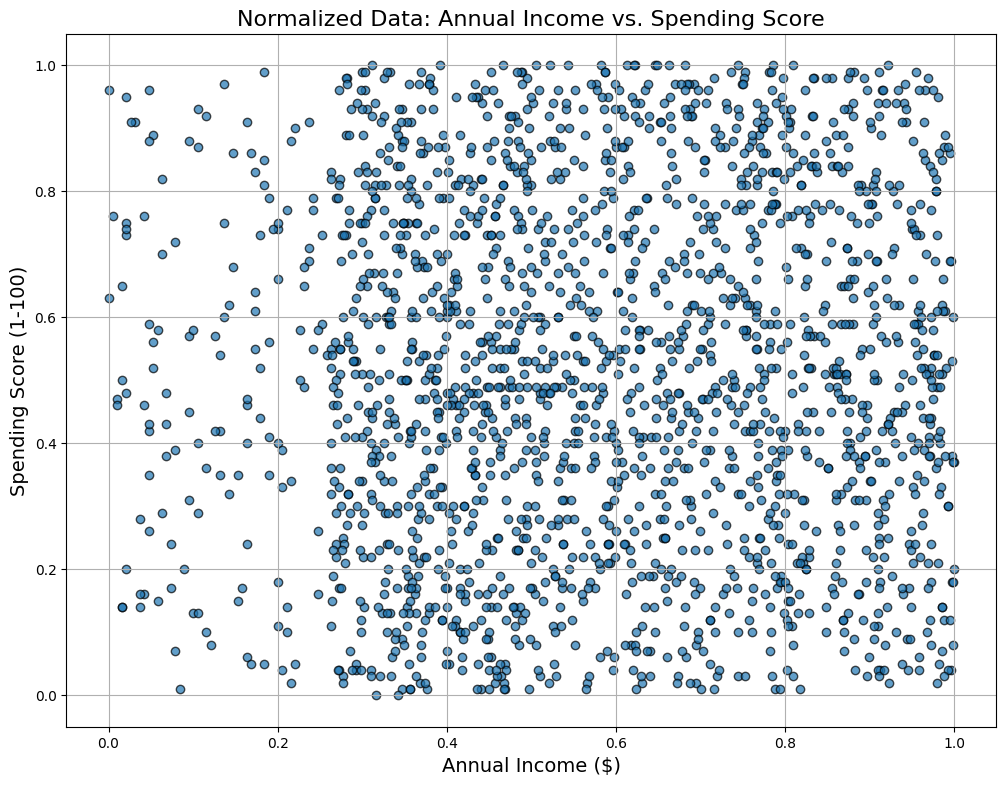

In [64]:
plt.figure(figsize=(12, 9))

# Create a scatter plot for normalized features
plt.scatter(normalized_features_df['Annual Income ($)'], 
            normalized_features_df['Spending Score (1-100)'], 
            alpha=0.7, edgecolor='k')

# Add titles and labels
plt.title('Normalized Data: Annual Income vs. Spending Score', fontsize=16)
plt.xlabel('Annual Income ($)', fontsize=14)
plt.ylabel('Spending Score (1-100)', fontsize=14)

# Show grid for better readability
plt.grid(True)

# Display the plot
plt.show()


In [65]:
# Convert the normalized features DataFrame to a NumPy array
X_array = normalized_features_df.to_numpy()

# Print the shape of the resulting NumPy array
print("Shape of the normalized features array:", X_array.shape)

# Display the contents of the normalized features array
display(X_array)


Shape of the normalized features array: (2000, 2)


array([[0.07895817, 0.39      ],
       [0.18423574, 0.81      ],
       [0.45269353, 0.06      ],
       ...,
       [0.47880763, 0.14      ],
       [0.9585996 , 0.04      ],
       [0.58223757, 0.52      ]])

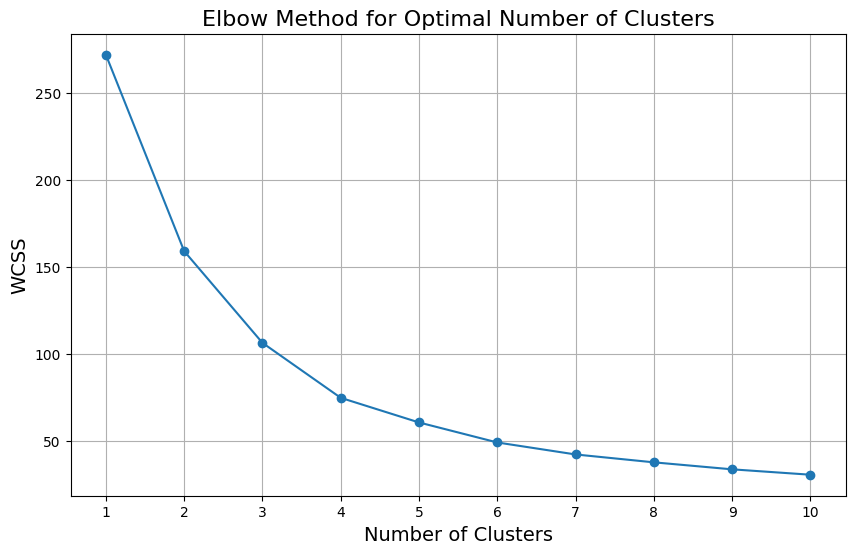

In [66]:
def plot_elbow_method(data, max_clusters=10):
    """
    Plots the Elbow Method for determining the optimal number of clusters.
    
    Parameters:
    - data: Input data for clustering.
    - max_clusters: Maximum number of clusters to test (default is 10).
    """
    wcss = []  # List to store WCSS values

    for num_clusters in range(1, max_clusters + 1):
        kmeans = KMeans(n_clusters=num_clusters, init='k-means++', max_iter=300, n_init=10, random_state=0)
        kmeans.fit(data)
        wcss.append(kmeans.inertia_)  # Append WCSS value

    plt.figure(figsize=(10, 6))  # Set figure size
    plt.plot(range(1, max_clusters + 1), wcss, marker='o')  # Plot WCSS values
    plt.title('Elbow Method for Optimal Number of Clusters', fontsize=16)
    plt.xlabel('Number of Clusters', fontsize=14)
    plt.ylabel('WCSS', fontsize=14)
    plt.xticks(range(1, max_clusters + 1))  # Show x-ticks for clusters
    plt.grid(True)  # Add grid for clarity
    plt.show()  # Display the plot


# Call the function to plot the Elbow Method using the normalized features
plot_elbow_method(X_array)


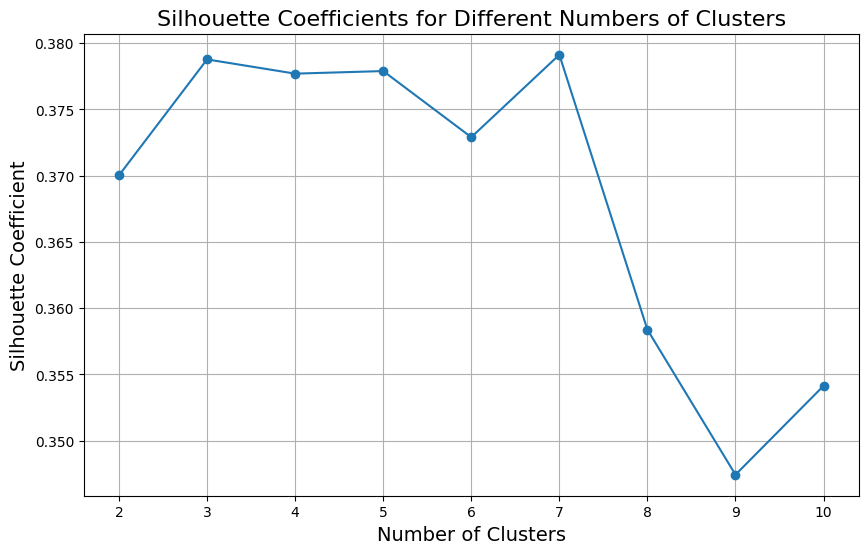

In [67]:
def calculate_and_plot_silhouette_scores(data, min_clusters=2, max_clusters=10):
    """
    Calculates silhouette scores for a range of cluster counts and plots the results.
    Setting min_clusters = 2 is needed for useful grouping, since silhouette scores don't work with one cluster.
    
    Parameters:
    - data: Input data for clustering.
    - min_clusters: Minimum number of clusters to evaluate (default is 2).
    - max_clusters: Maximum number of clusters to evaluate (default is 10).
    """
    silhouette_scores = []  # List to store silhouette scores

    for k in range(min_clusters, max_clusters + 1):
        kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=0)
        kmeans.fit(data)
        score = silhouette_score(data, kmeans.labels_)  # Calculate silhouette score
        silhouette_scores.append(score)  # Append score to list

    # Plot the silhouette scores
    plt.figure(figsize=(10, 6))
    plt.plot(range(min_clusters, max_clusters + 1), silhouette_scores, marker='o')
    plt.xticks(range(min_clusters, max_clusters + 1))  # Set x-ticks for clusters
    plt.xlabel("Number of Clusters", fontsize=14)
    plt.ylabel("Silhouette Coefficient", fontsize=14)
    plt.title("Silhouette Coefficients for Different Numbers of Clusters", fontsize=16)
    plt.grid(True)  # Add grid for better readability
    plt.show()  # Display the plot

# Call the function to calculate and plot silhouette scores
calculate_and_plot_silhouette_scores(X_array)


In [68]:
# Set parameters for KMeans clustering
num_clusters = 7
max_iterations = 500
num_init = 10

# Perform KMeans clustering on the data
kmeans = KMeans(n_clusters=num_clusters, max_iter=max_iterations, n_init=num_init, random_state=0)
kmeans_predictions = kmeans.fit_predict(X_array)

# Display the KMeans cluster predictions
display(kmeans_predictions)


array([0, 5, 3, ..., 3, 6, 4])

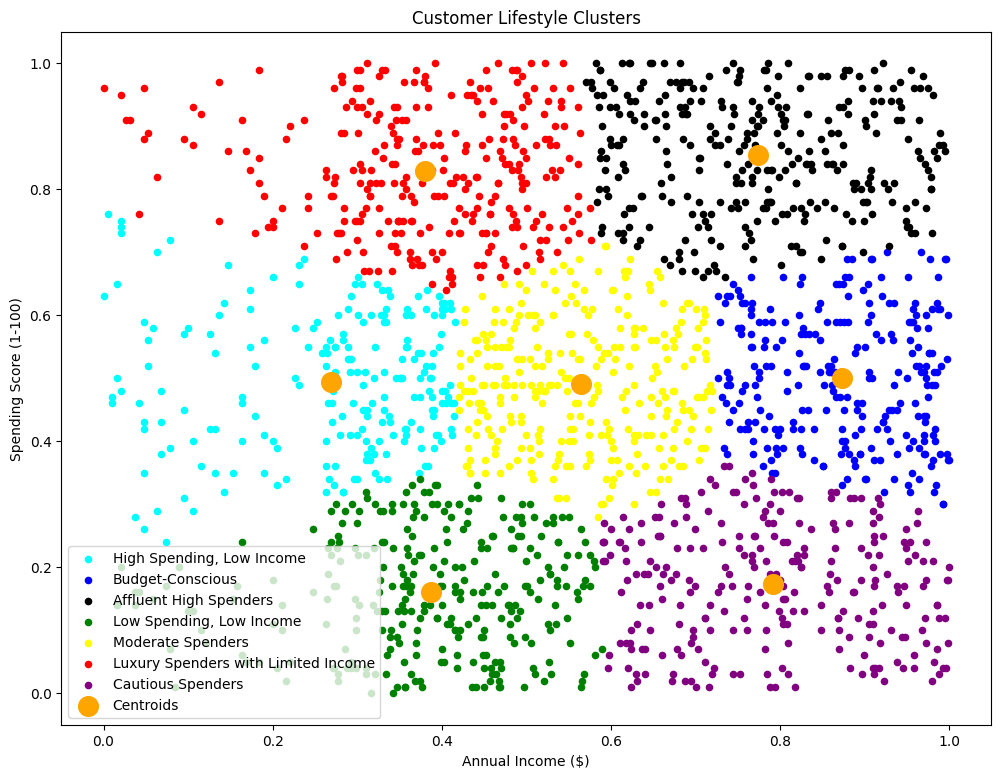

In [69]:
# Colors for the 7 clusters
colors = ['cyan', 'blue', 'black', 'green', 'yellow', 'red', 'purple']

# Cluster labels
labels = [
    'High Spending, Low Income',
    'Budget-Conscious',
    'Affluent High Spenders',
    'Low Spending, Low Income',
    'Moderate Spenders',
    'Luxury Spenders with Limited Income',
    'Cautious Spenders'
]

# Scatter plot of client lifestyle clusters based on Annual Income and Spending Score, with centroids highlighted.
plt.figure(figsize=(12, 9))
for i in range(7):
    plt.scatter(X_array[kmeans_predictions == i, 0], X_array[kmeans_predictions == i, 1], c=colors[i], label=labels[i], s=20)

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='orange', label='Centroids')
plt.title('Customer Lifestyle Clusters')
plt.xlabel('Annual Income ($)')
plt.ylabel('Spending Score (1-100)')
plt.legend(loc='best')
plt.show()


In [70]:
# Assign cluster labels to the DataFrame
customer_data['Cluster'] = kmeans_predictions

# Display the updated DataFrame
display(customer_data.head())


,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size,Cluster
0,1,Male,19,15000,39,Healthcare,1,4,0
1,2,Male,21,35000,81,Engineer,3,3,5
2,3,Female,20,86000,6,Engineer,1,1,3
3,4,Female,23,59000,77,Lawyer,0,2,5
4,5,Female,31,38000,40,Entertainment,2,6,0


In [71]:
# Count the number of entries in each cluster
cluster_counts = customer_data.groupby('Cluster')['Cluster'].count()

# Display the count of each cluster
display(cluster_counts)


Cluster
0    221
1    265
2    324
3    303
4    307
5    306
6    274
Name: Cluster, dtype: int64

In [72]:
# Display the first 5 entries for Cluster 2
display(customer_data.loc[customer_data['Cluster'] == 2].head())


,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size,Cluster
273,274,Female,18,143000,99,Artist,0,2,2
286,287,Female,85,140000,84,Entertainment,1,1,2
300,301,Male,85,153787,100,Entertainment,3,3,2
302,303,Female,31,145015,73,Healthcare,6,3,2
308,309,Male,26,112766,83,Engineer,8,4,2


In [73]:
# Create a DataFrame with cluster labels
clustered_data = customer_data.copy()
clustered_data['Cluster'] = kmeans_predictions

# Get summary statistics for each cluster
cluster_summary = clustered_data.groupby('Cluster')[features_name].mean()
display(cluster_summary)


,Annual Income ($),Spending Score (1-100)
Cluster,,
0,51081.624434,49.457014
1,165884.052830,50.018868
2,147050.530864,85.450617
3,73491.739274,16.066007
4,107310.768730,49.058632
5,72411.114379,82.859477
6,150367.715328,17.408759


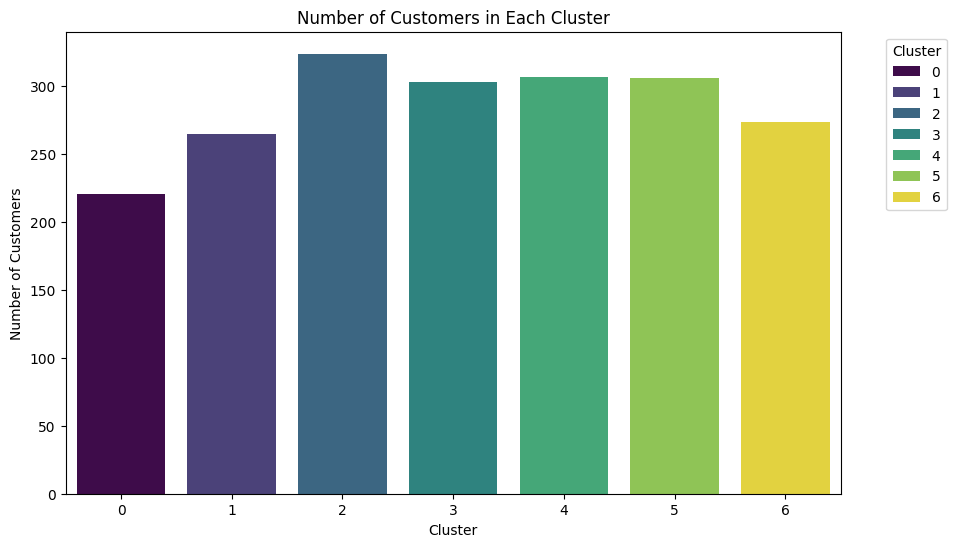

In [74]:
# Create a bar plot for cluster sizes
plt.figure(figsize=(10, 6))

# Create a DataFrame for plotting
cluster_counts_df = pd.DataFrame({'Cluster': cluster_counts.index, 'Count': cluster_counts.values})

# Bar plot showing the number of customers in each cluster.
sns.barplot(x='Cluster', y='Count', data=cluster_counts_df, hue='Cluster', palette='viridis', dodge=False)
plt.title('Number of Customers in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


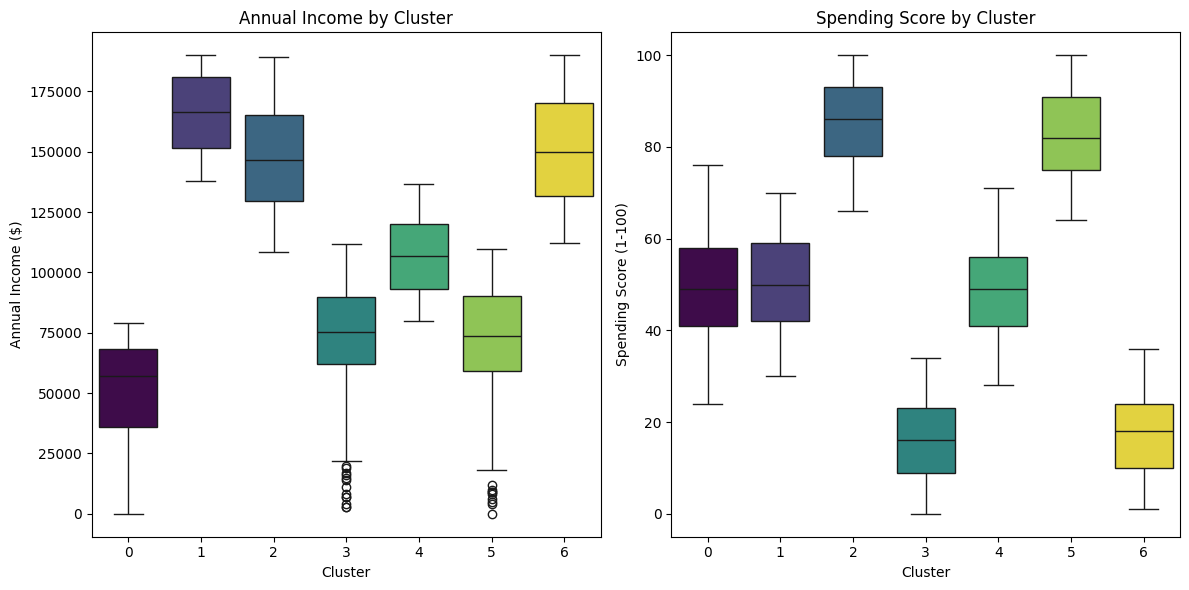

In [75]:
# Box plots for Annual Income and Spending Score by Cluster
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='Cluster', y='Annual Income ($)', data=clustered_data, hue='Cluster', palette='viridis', legend=False)
plt.title('Annual Income by Cluster')

plt.subplot(1, 2, 2)
sns.boxplot(x='Cluster', y='Spending Score (1-100)', data=clustered_data, hue='Cluster', palette='viridis', legend=False)
plt.title('Spending Score by Cluster')

plt.tight_layout()
plt.show()


In [76]:
# Select relevant features
customer_features = clustered_data[['Age', 'Family Size']]

# Create an instance of MinMaxScaler for normalization
minmax_scaler = MinMaxScaler()

# Fit and transform the features
normalized_customer_features = minmax_scaler.fit_transform(customer_features)

# Convert the normalized data back into a DataFrame with the same column names
normalized_features_df = pd.DataFrame(normalized_customer_features, columns=['Age', 'Family Size'])

# Calculate and display the peak-to-peak range for the raw numerical features
print(f"Peak to Peak range by column in Raw        :\n{np.ptp(customer_features, axis=0)}")   

# Calculate and display the peak-to-peak range for the normalized features
print(f"Peak to Peak range by column in Normalized :\n{np.ptp(normalized_features_df, axis=0)}")

# Print the normalized features
print(normalized_features_df)


Peak to Peak range by column in Raw        :
Age            99
Family Size     8
dtype: int64
Peak to Peak range by column in Normalized :
Age            1.0
Family Size    1.0
dtype: float64
           Age  Family Size
0     0.191919        0.375
1     0.212121        0.250
2     0.202020        0.000
3     0.232323        0.125
4     0.313131        0.625
...        ...          ...
1995  0.717172        0.750
1996  0.919192        0.750
1997  0.878788        0.125
1998  0.777778        0.125
1999  0.909091        0.125

[2000 rows x 2 columns]


In [77]:
# Get statistics for the normalized features DataFrame
normalized_statistics = normalized_features_df.describe()

# Display the statistics
display(normalized_statistics)


,Age,Family Size
count,2000.000000,2000.000000
mean,0.494545,0.346062
std,0.287169,0.246344
min,0.000000,0.000000
25%,0.252525,0.125000
50%,0.484848,0.375000
75%,0.737374,0.500000
max,1.000000,1.000000


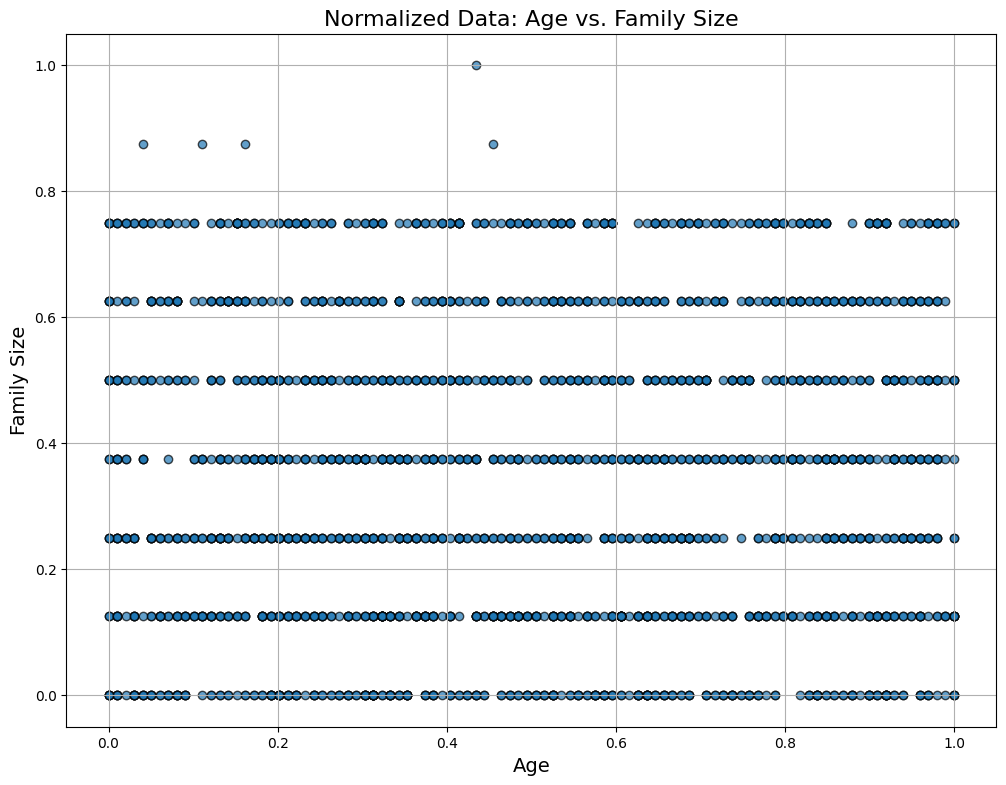

In [78]:
plt.figure(figsize=(12, 9))

# Create a scatter plot for normalized features
plt.scatter(normalized_features_df['Age'], 
            normalized_features_df['Family Size'], 
            alpha=0.7, edgecolor='k')

# Add titles and labels
plt.title('Normalized Data: Age vs. Family Size', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Family Size', fontsize=14)

# Show grid for better readability
plt.grid(True)

# Display the plot
plt.show()


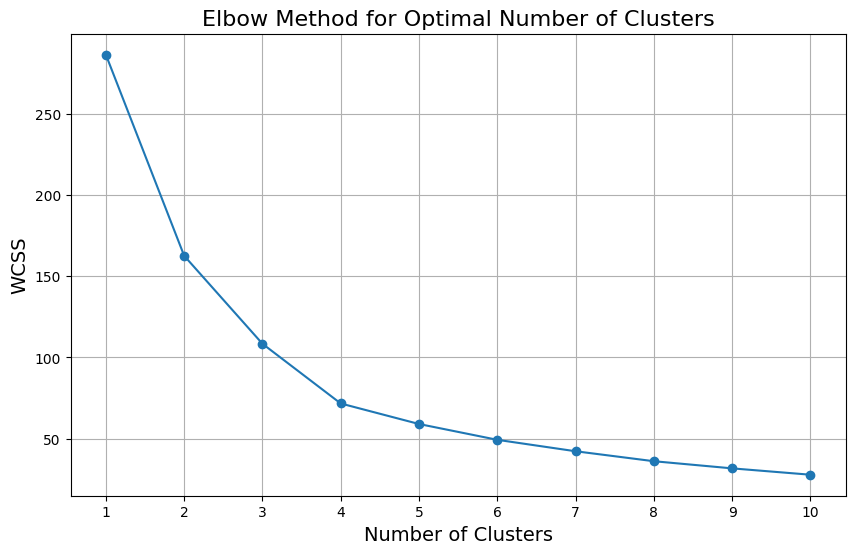

In [83]:
plot_elbow_method(normalized_features_df)


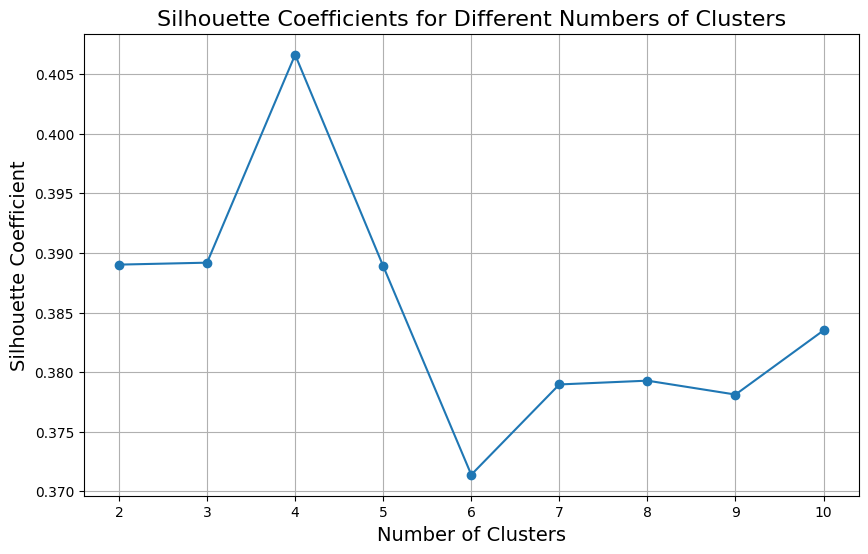

In [84]:
calculate_and_plot_silhouette_scores(normalized_features_df)


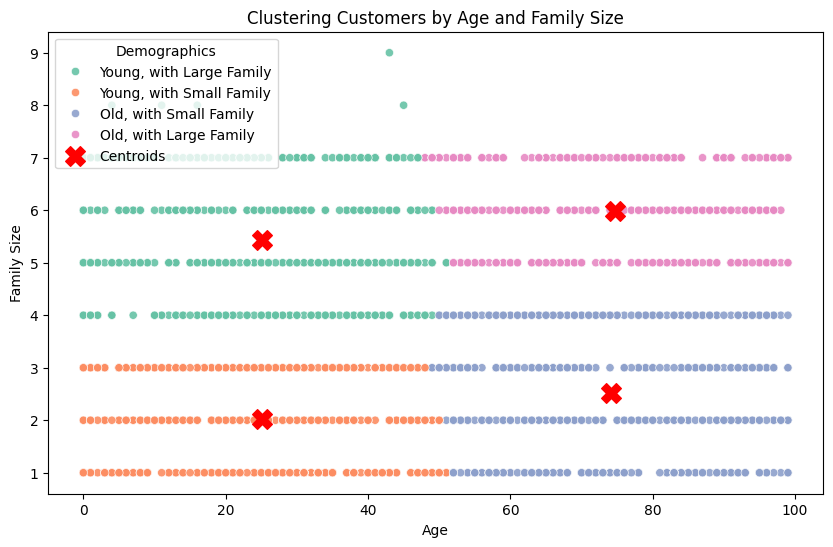

In [85]:
# Choose 4 as optimal number of clusters
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=0)
clustered_data['Cluster'] = kmeans.fit_predict(normalized_features_df)

# Map numerical clusters to descriptive names
cluster_names = {
    0: 'Old, with Large Family',
    1: 'Young, with Small Family',
    2: 'Old, with Small Family',
    3: 'Young, with Large Family'
}
clustered_data['Demographics'] = clustered_data['Cluster'].replace(cluster_names)

# Plotting the clusters with cluster names
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Family Size', hue='Demographics', data=clustered_data, palette='Set2', alpha=0.9)

# Calculate and plot the centroids
centers = minmax_scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=['Age', 'Family Size'])
plt.scatter(centers_df['Age'], centers_df['Family Size'], c='red', marker='X', s=200, label='Centroids')

# Adding titles and labels
plt.title('Clustering Customers by Age and Family Size')
plt.xlabel('Age')
plt.ylabel('Family Size')
plt.legend(title='Demographics')
plt.show()


In [86]:
# Assign the 'Cluster' column from customer_data to clustered_data and rename it to 'LifeStyle'
clustered_data['Cluster'] = customer_data['Cluster']
clustered_data.rename(columns={'Cluster': 'LifeStyle'}, inplace=True)

# Map numerical clusters to descriptive names
cluster_names = {
    0: 'High Spending, Low Income',
    1: 'Budget-Conscious',
    2: 'Affluent High Spenders',
    3: 'Low Spending, Low Income',
    4: 'Moderate Spenders',
    5: 'Luxury Spenders with Limited Income',
    6: 'Cautious Spenders'
}
# Replace numerical Clusters in 'LifeStyle' with their corresponding descriptive names
clustered_data['LifeStyle'] = clustered_data['LifeStyle'].replace(cluster_names)


In [87]:
display(clustered_data)


,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size,LifeStyle,Demographics
0,1,Male,19,15000,39,Healthcare,1,4,"High Spending, Low Income","Young, with Large Family"
1,2,Male,21,35000,81,Engineer,3,3,Luxury Spenders with Limited Income,"Young, with Small Family"
2,3,Female,20,86000,6,Engineer,1,1,"Low Spending, Low Income","Young, with Small Family"
3,4,Female,23,59000,77,Lawyer,0,2,Luxury Spenders with Limited Income,"Young, with Small Family"
4,5,Female,31,38000,40,Entertainment,2,6,"High Spending, Low Income","Young, with Large Family"
...,...,...,...,...,...,...,...,...,...,...
1995,1996,Female,71,184387,40,Artist,8,7,Budget-Conscious,"Old, with Large Family"
1996,1997,Female,91,73158,32,Doctor,7,7,"Low Spending, Low Income","Old, with Large Family"
1997,1998,Male,87,90961,14,Healthcare,9,2,"Low Spending, Low Income","Old, with Small Family"
1998,1999,Male,77,182109,4,Executive,7,2,Cautious Spenders,"Old, with Small Family"


In [88]:
# Filter data for 'Cautious Spenders' and 'Old, with Small Family'
filtered_data = clustered_data.loc[
    (clustered_data['LifeStyle'] == 'Cautious Spenders') & 
    (clustered_data['Demographics'] == 'Old, with Small Family')
]

# Display all entries for the cluster with 'Cautious Spenders' lifestyle and 'Old, with Small Family' demographics
display(filtered_data)


,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size,LifeStyle,Demographics
304,305,Female,90,117319,21,Lawyer,1,2,Cautious Spenders,"Old, with Small Family"
305,306,Female,65,180243,26,Marketing,6,2,Cautious Spenders,"Old, with Small Family"
306,307,Female,63,165052,12,Artist,4,2,Cautious Spenders,"Old, with Small Family"
307,308,Female,61,120487,14,Doctor,0,2,Cautious Spenders,"Old, with Small Family"
316,317,Female,54,132046,8,Homemaker,4,4,Cautious Spenders,"Old, with Small Family"
...,...,...,...,...,...,...,...,...,...,...
1891,1892,Male,71,149318,27,Artist,4,1,Cautious Spenders,"Old, with Small Family"
1893,1894,Female,68,173047,17,Healthcare,0,3,Cautious Spenders,"Old, with Small Family"
1966,1967,Male,65,134213,32,Homemaker,8,4,Cautious Spenders,"Old, with Small Family"
1992,1993,Male,94,181183,24,Marketing,9,3,Cautious Spenders,"Old, with Small Family"


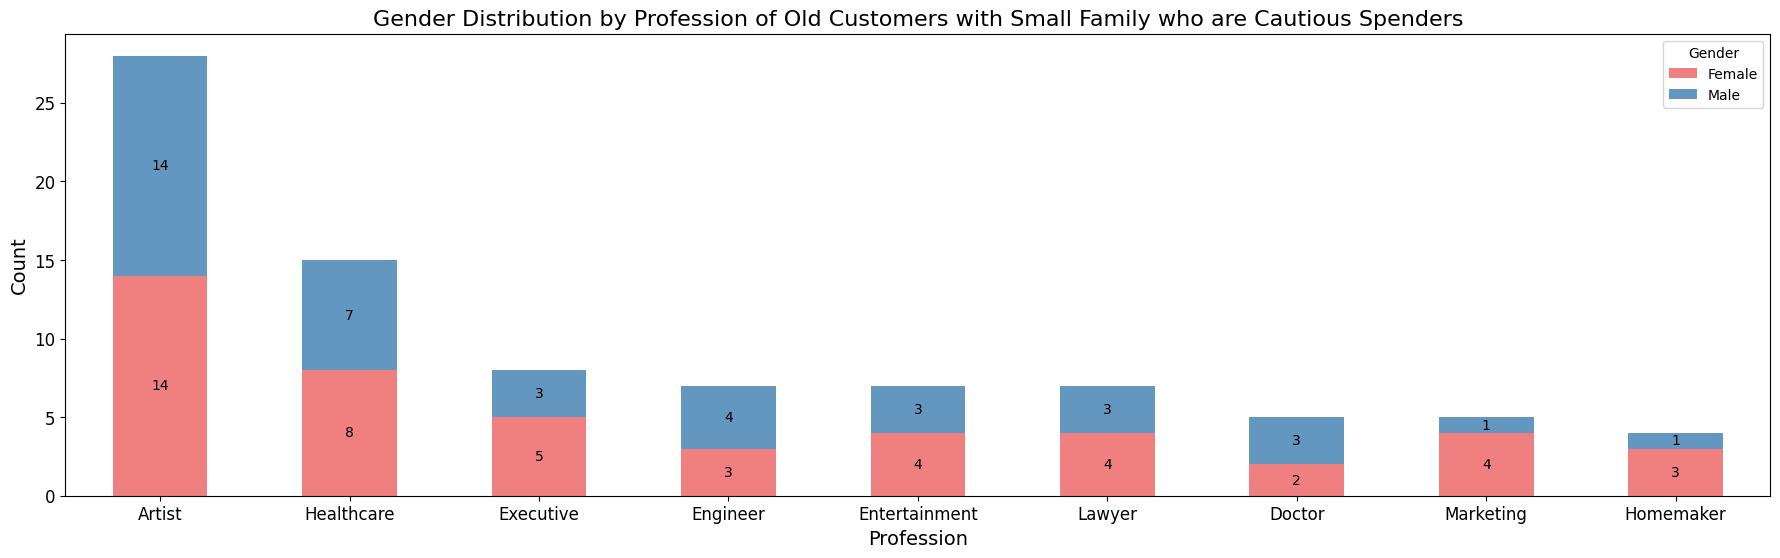

In [89]:
# Create a cross-tabulation of professions by gender
gender_profession_counts = pd.crosstab(filtered_data['Profession'], filtered_data['Gender'])

# Sort indices based on the total count of each profession
professions_sorted = gender_profession_counts.sum(axis=1).sort_values(ascending=False).index 

# Create a stacked bar plot for profession vs. gender with specified colors
ax = gender_profession_counts.loc[professions_sorted, :].plot(
    kind="bar", 
    stacked=True, 
    figsize=(22, 6), 
    color=['#F08080', '#6497BF']
)

# Set x and y ticks
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

# Add labels to the bars
ax.bar_label(ax.containers[0], label_type='center')
ax.bar_label(ax.containers[1], label_type='center')

# Add titles and labels
plt.title('Gender Distribution by Profession of Old Customers with Small Family who are Cautious Spenders', fontsize=16)
plt.xlabel('Profession', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Show the plot
plt.show()


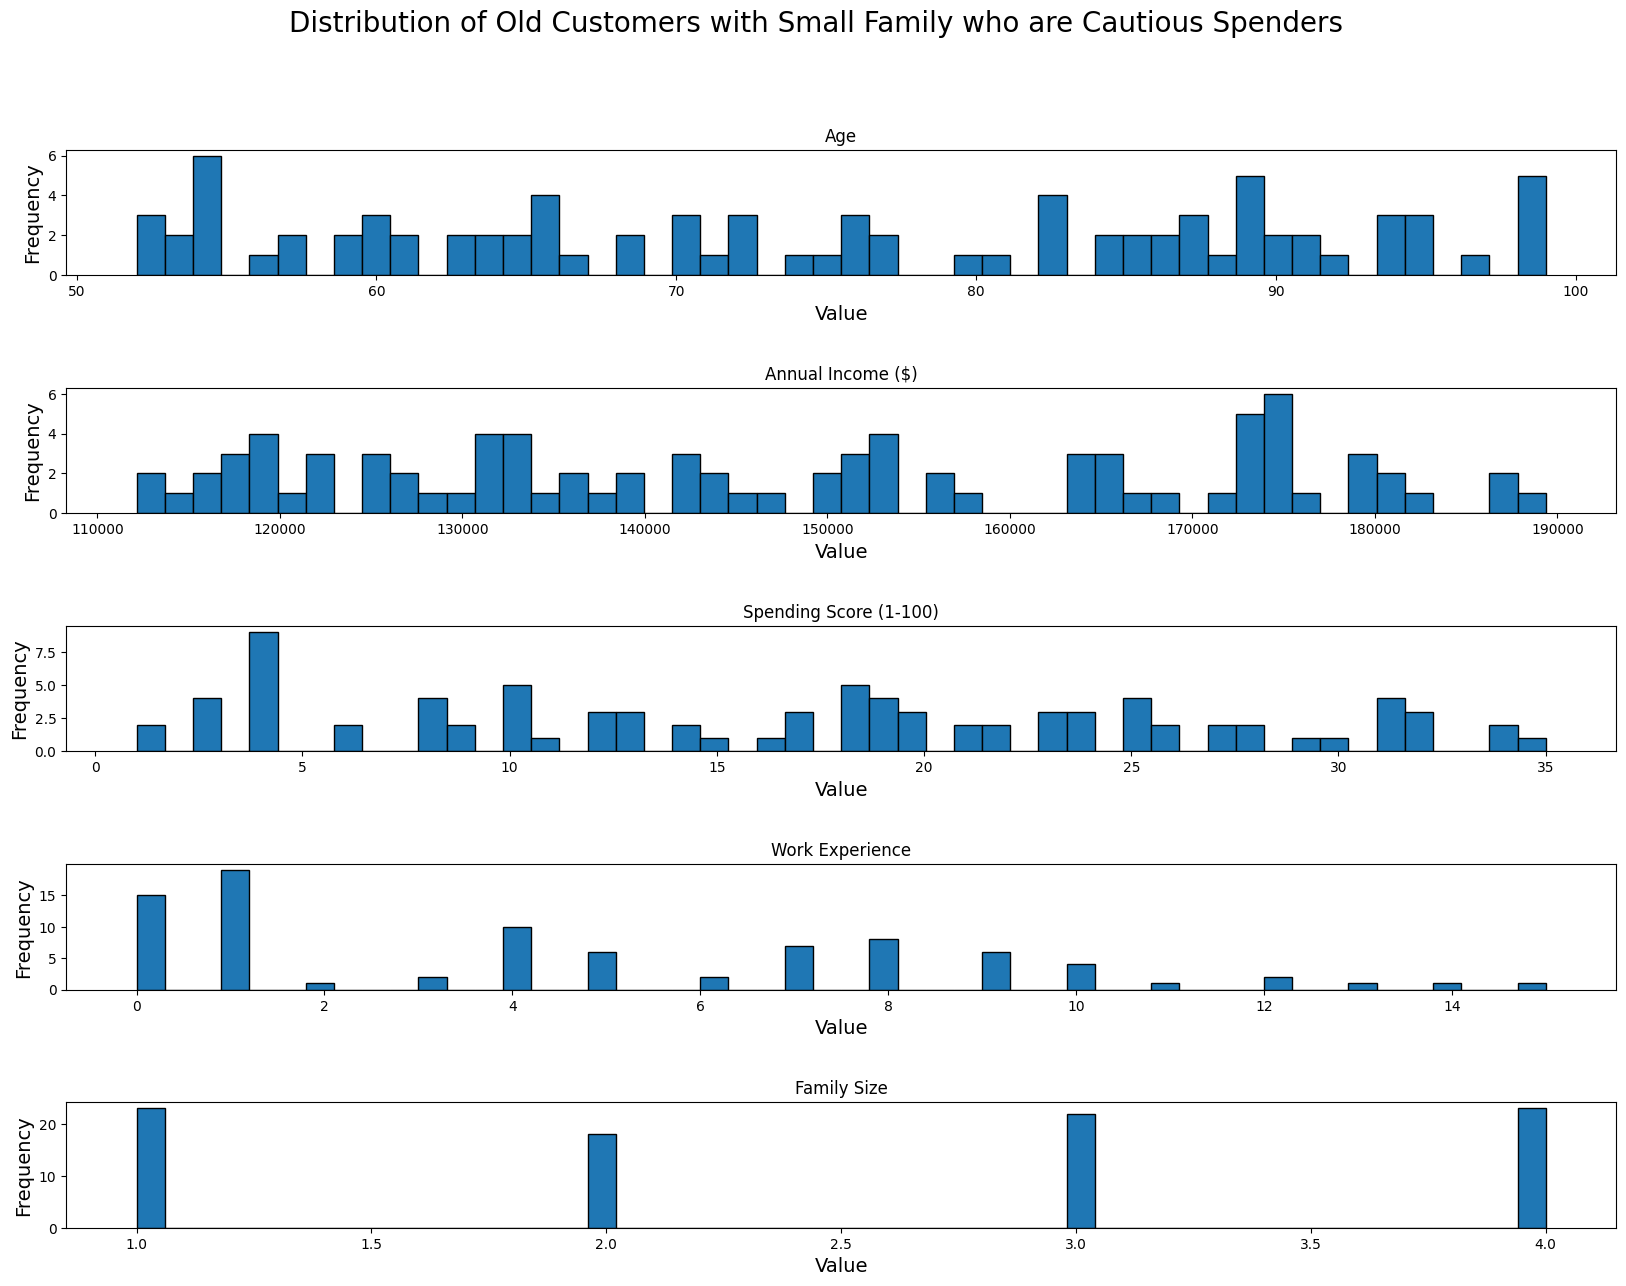

In [90]:
# Exclude 'CustomerID' and select only numeric columns
num_data = filtered_data.drop(columns=['CustomerID']).select_dtypes(include=['number'])
num_col = num_data.shape[1]

plt.figure(figsize=(20, 14))

# Create histograms for each numeric column
for i, column in enumerate(num_data.columns):
    plt.subplot(num_col, 1, i + 1)  # Create a subplot for each column
    plt.hist(num_data[column], bins=50, edgecolor='black')
    plt.title(column) 
    plt.xlabel('Value', fontsize=14) 
    plt.ylabel('Frequency', fontsize=14)

# Adjust the layout to add spacing
plt.subplots_adjust(hspace=0.9)

# Title for the entire figure
plt.suptitle('Distribution of Old Customers with Small Family who are Cautious Spenders', fontsize=20)

# Show the plot
plt.show()
